In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df=pd.read_csv("heart_disease_uci.csv")

In [4]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [5]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [7]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [8]:
def target(num):
    if num>0:
        return 1;
    else:
        return 0

In [9]:
df["target"]=df["num"].apply(target)

In [10]:
df=df.drop(columns=["id","num"])

In [11]:
df.columns

Index(['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [13]:
df.shape

(920, 15)

<Axes: xlabel='sex', ylabel='count'>

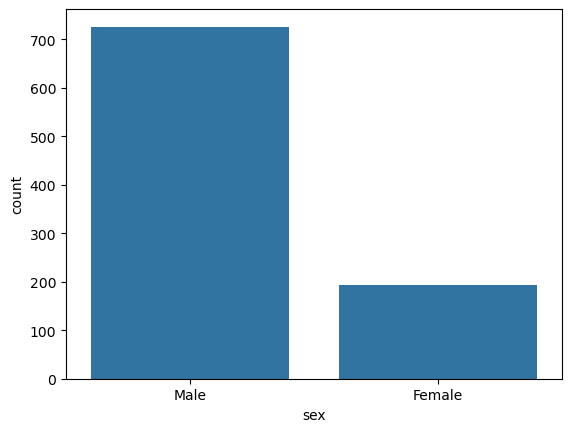

In [14]:
# univariate analysis
sns.countplot(x="sex",data=df)
# jyadatar mail so hear diseace hai 

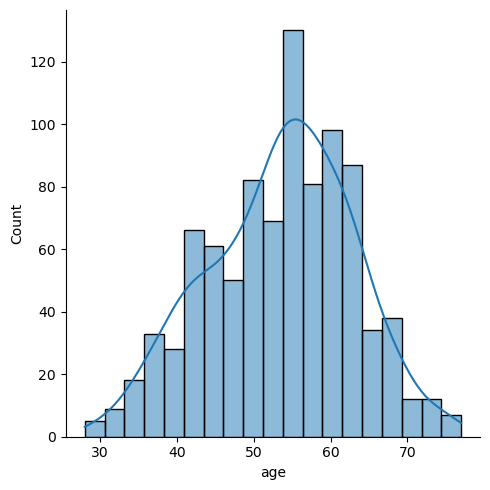

In [15]:
sns.displot(df["age"],kde=True)

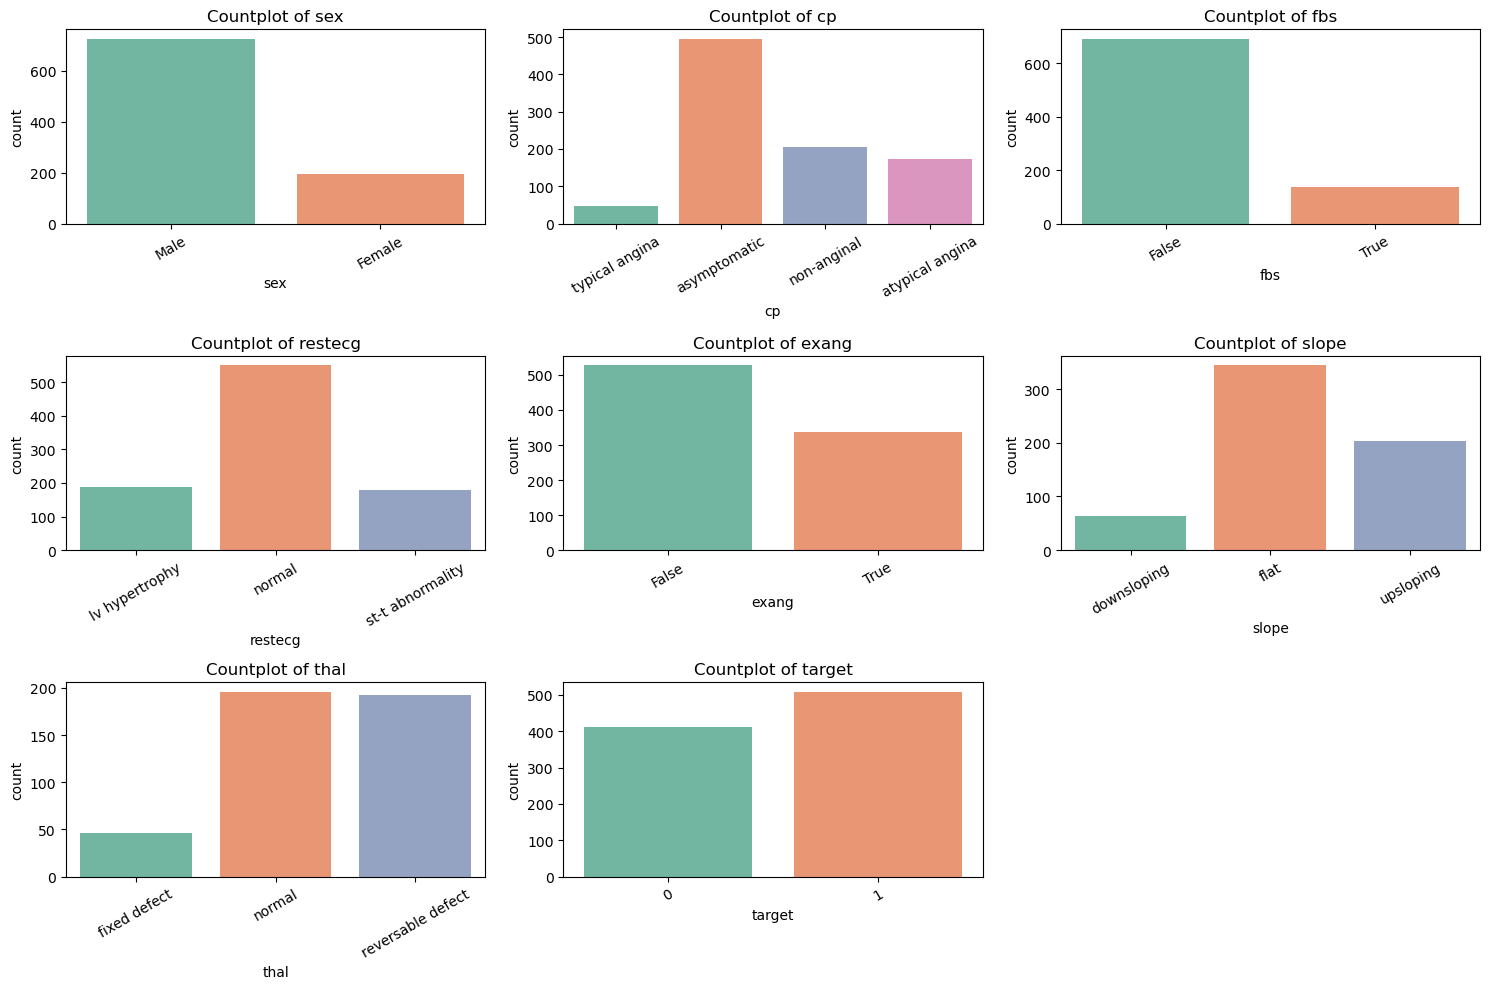

In [16]:
import warnings
warnings.filterwarnings('ignore')
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, data=df, palette='Set2')
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

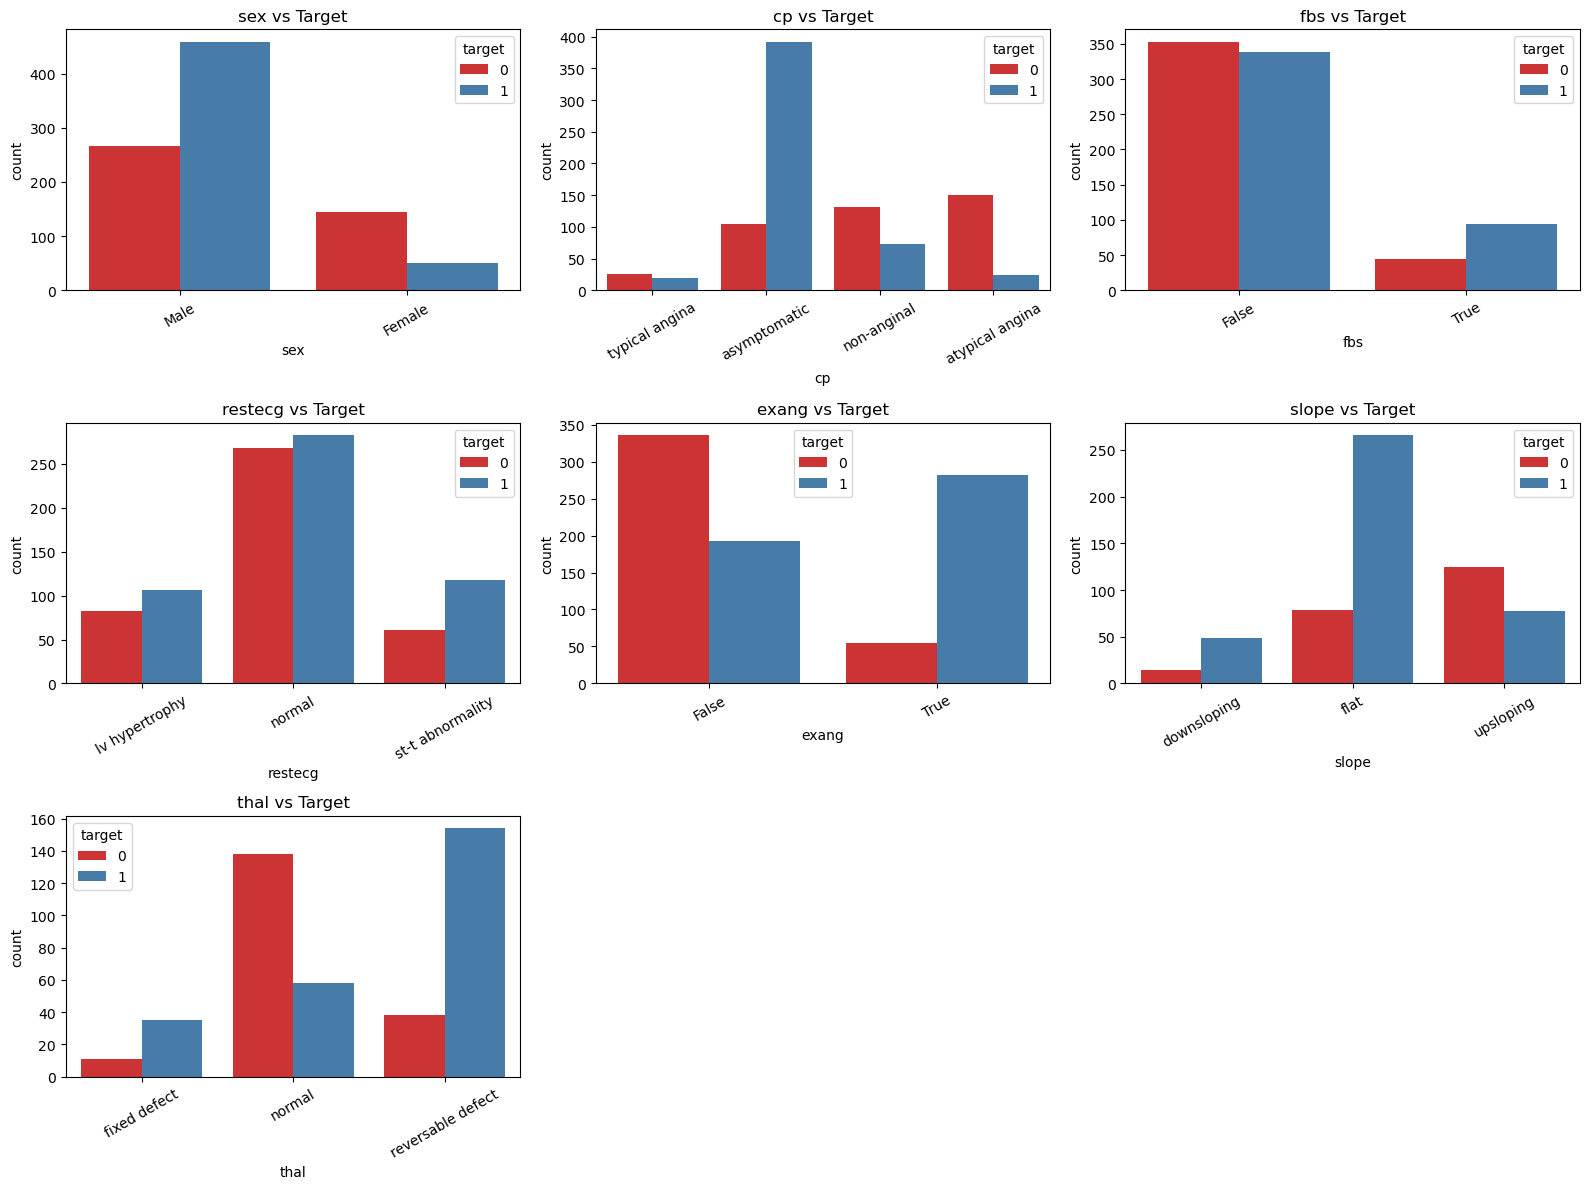

In [17]:
# bivariate analusis
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
plt.figure(figsize=(16, 12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, hue='target', data=df, palette='Set1')
    plt.title(f'{col} vs Target')
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

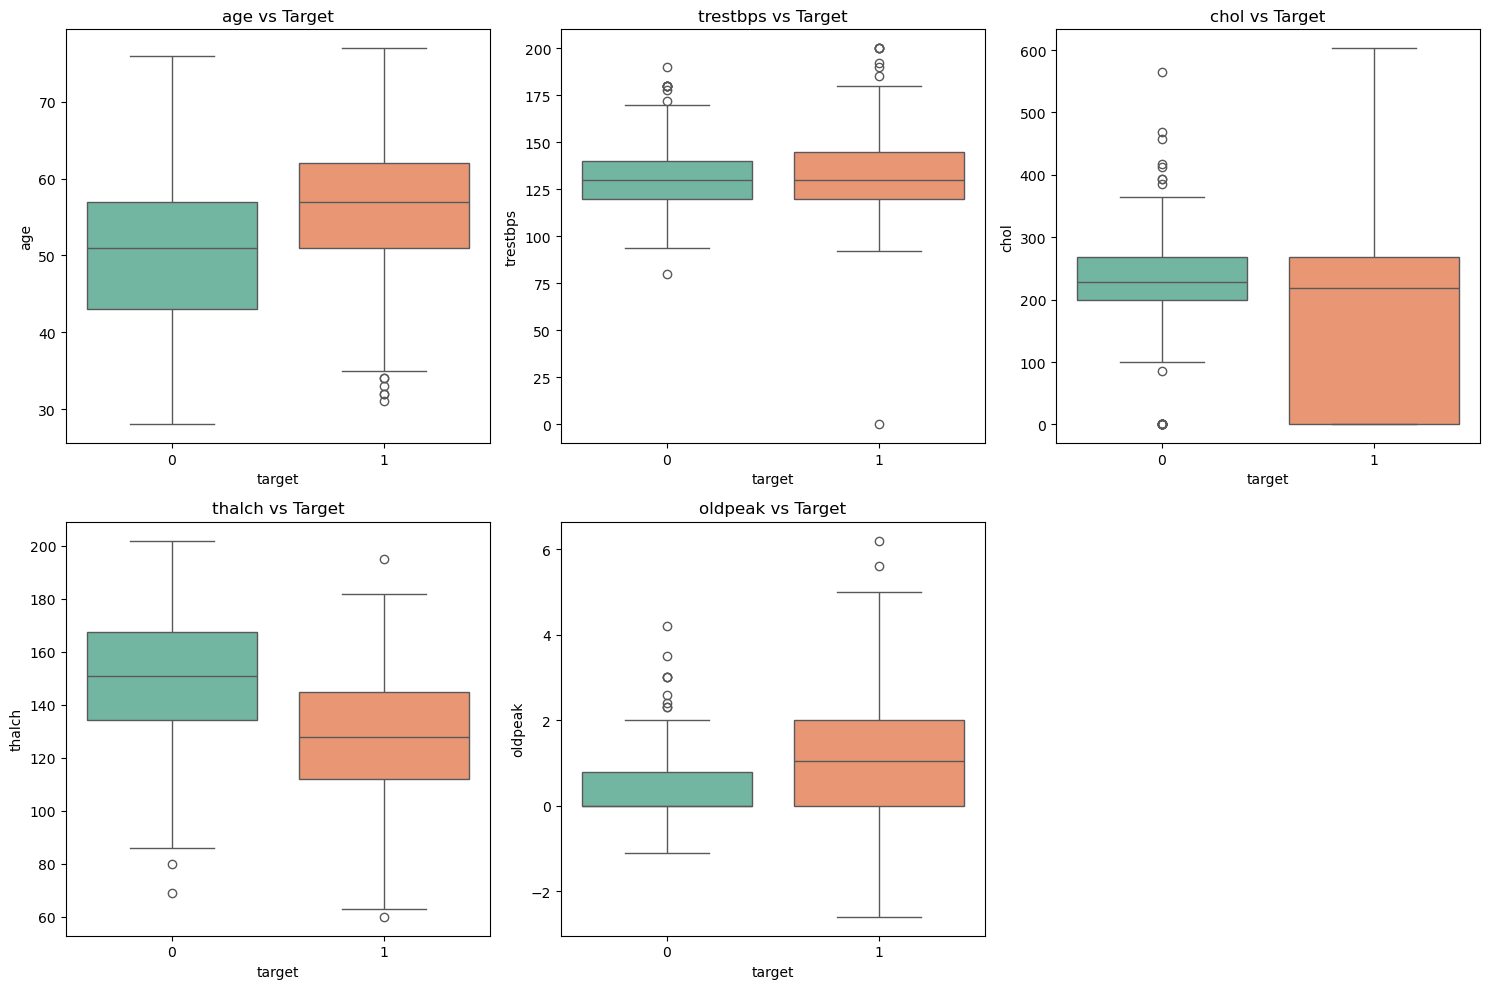

In [18]:
# Numerical Features vs Target
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='target', y=col, data=df, palette='Set2')
    plt.title(f'{col} vs Target')

plt.tight_layout()
plt.show()

In [12]:
df["chol"]=df["chol"].replace(0,np.nan)
df["trestbps"]=df["trestbps"].replace(0,np.nan)

In [19]:
x=df.drop(columns=["target"])
y=df["target"]

In [20]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.20,random_state=42)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [34]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
low_cat = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang']
high_cat = ['slope', 'ca', 'thal']
for col in low_cat + high_cat:
    xtrain[col] = xtrain[col].astype(str)
    xtest[col] = xtest[col].astype(str)
tnf1 = ColumnTransformer(transformers=[
    ('num_tr', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    
    ('low_cat_tr', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]), low_cat),
    
    ('high_cat_tr', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]), high_cat)
], remainder='passthrough')

model = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

In [35]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline

=== Logistic Regression ===
=== Decision Tree ===
Accuracy : 0.7663
Recall   : 0.7431
F1 Score : 0.7902

Best Model: Logistic Regression


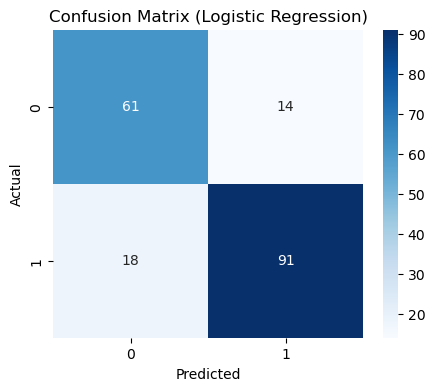

In [39]:
results = {}
pipelines = {}
for model_name, model_obj in model.items():
    pipe = Pipeline([
        ('tnf1', tnf1),
        ('model', model_obj)
    ])
    pipe.fit(xtrain, ytrain)
    ypred = pipe.predict(xtest)
    
    acc = accuracy_score(ytest, ypred)
    rec = recall_score(ytest, ypred)
    f1 = f1_score(ytest, ypred)
    
    pipelines[model_name] = pipe
    results[model_name] = {
        'Accuracy': acc,
        'Recall': rec,
        'F1 Score': f1,
        'ypred': ypred
    }
    print(f"=== {model_name} ===")
print(f"Accuracy : {acc:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}\n")
best_model_name = max(results, key=lambda k: results[k]['F1 Score'])
best_pipeline = pipelines[best_model_name]
best_ypred = results[best_model_name]['ypred']
print(f"Best Model: {best_model_name}")
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(ytest, best_ypred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix ({best_model_name})')
plt.show()

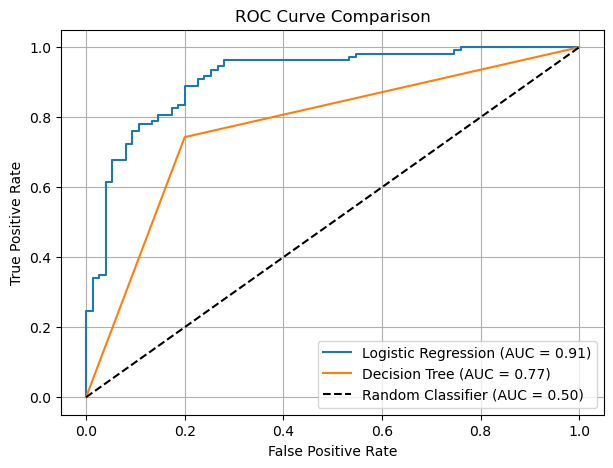

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 5))
for model_name, pipe in pipelines.items():
    if hasattr(pipe, "predict_proba"):
        y_probs = pipe.predict_proba(xtest)[:, 1]
    else:
        y_probs = pipe.decision_function(xtest)
    fpr, tpr, _ = roc_curve(ytest, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Project Summary & Final Conclusions

### 1. Objective
The main goal of this project was to predict whether a patient is likely to have heart disease using clinical features from the Heart Disease UCI dataset.

### 2. Models Evaluated
- Logistic Regression
- Decision Tree Classifier

### 3. Model Performance Comparison
- Logistic Regression: Accuracy = 82.61% | Recall = 83.49% | F1 Score = 0.8505 | AUC-ROC = 0.91
- Decision Tree: Accuracy = 76.63% | Recall = 74.31% | F1 Score = 0.7902 | AUC-ROC = 0.77

### 4. Key Findings
- Winner Model: Logistic Regression outperformed the Decision Tree across all metrics (Accuracy, Recall, and F1 Score).
- ROC-AUC Score: Logistic Regression achieved an AUC score of 0.91, demonstrating excellent class separation capability.
- Recall Focus: High Recall (83.49%) is critical in medical diagnosis to minimize False Negatives (avoiding missing a diseased patient).

### 5. Final Outcome
The fitted Logistic Regression Pipeline (`best_pipeline`) has been selected as the final production model for heart disease risk prediction.